<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/notebooks/kan_vs_mlp_sp1_1sreda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Часть 1. Генерация данных**

Установка библиотек + проверка устройства

In [1]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-hi9fw_8a
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-hi9fw_8a
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.2.8-py3-none-any.whl size=78235 sha256=128876080e4259a7d01a6667da63bb144cbd32301e8a72ecb49454f1aadebf08
  Stored in directory: /tmp/pip-ephem-wheel-cache-cpqmwxww/wheels/e5/c9/d6/a9b7aad8b3f7e1dde415462c7dd48df332ec616b149d51bcb8
Successfully built pykan
Работает на устройстве: cpu


Генерация траекторий численным интегрированием: координата *x(t)*, скорость *v(t)* и ускорение *a(t)*

In [2]:
k, m, c = 4.0, 1.0, 0.3  # жёсткость, масса, сопротивление среды

def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []

for x0 in [1.0, 0.5, 2.0]: # цикл по начальным условиям
    for v0 in [0.0, 0.5, -0.5]:

        sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 20, 500))
        # запуск численного интегрирования от t[0,20], 500 значений

        x, v = sol.y # извлечение из результата (sol) массив из координат и скоростей
        a = -(k/m)*x - (c/m)*v # вычисление ускорения

        for i in range(len(x)): # сохрание точек (x, v, a)
            all_data.append([x[i], v[i], a[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")   # 9 траекторий × 500 = 4500

Всего точек: 4500


Формирование датасета из полученных данных (входы: *x*,*v*, выход: *a*)

In [3]:
X = all_data[:, :2]   # (x, v)
y = all_data[:, 2]    # a

# pазбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование (рекомендуется для MLP, KAN тоже не мешает)
scaler_X = StandardScaler() # вход
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

scaler_y = StandardScaler() # выход
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1)).flatten()

# Преобразование в тензоры
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1,1)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32).reshape(-1,1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

train: 3600 примеров, test: 900 примеров


# **Часть 2. Создание и обучение KAN [2,2,1] (66 параметров)**

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.88e-02 | test_loss: 3.16e-02 | reg: 9.36e+00 | : 100%|█| 30/30 [00:07<00:00,  3.93it


saving model version 0.1


| train_loss: 2.65e-02 | test_loss: 2.84e-02 | reg: 9.34e+00 | : 100%|█| 30/30 [00:08<00:00,  3.44it


saving model version 0.2


...

saving model version 0.8


| train_loss: 2.38e-02 | test_loss: 2.71e-02 | reg: 9.22e+00 | : 100%|█| 30/30 [00:08<00:00,  3.62it


saving model version 0.9


| train_loss: 2.34e-02 | test_loss: 2.64e-02 | reg: 9.20e+00 | : 100%|█| 30/30 [00:08<00:00,  3.52it


saving model version 0.10
MSE KAN (scaled): 0.00069805


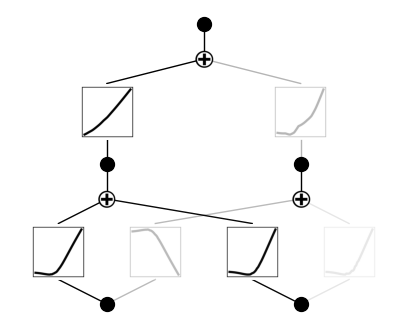

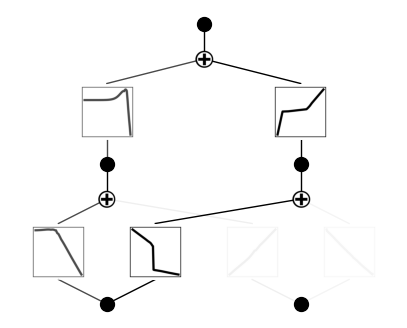

In [11]:
model_kan = KAN(width=[2, 2, 1], grid=10, k=1, seed=42, device=device)
# k=1 так как вычисляемая функция линейна, такого порядка сплайна достаточно

model_kan(dataset['train_input']) # инициализация, визуализация
model_kan.plot()

steps = 10
train_losses_kan = []
test_losses_kan = []
# обучаем по одному шагу, сохраняя потери
for step in range(steps):
    res = model_kan.fit(dataset, opt="LBFGS", steps=30, lamb=0.0, lamb_entropy=0.0)
    train_losses_kan.append(res['train_loss'])
    test_losses_kan.append(res['test_loss'])

model_kan.plot() # визуализация

# ошибка на тесте (в масштабированных единицах)
with torch.no_grad():
    pred_kan_scaled = model_kan(dataset['test_input'])
    mse_kan_scaled = nn.functional.mse_loss(pred_kan_scaled, dataset['test_label'])
print(f"MSE KAN (scaled): {mse_kan_scaled.item():.8f}")

Символьная регрессия

In [12]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model_kan.auto_symbolic(lib=lib)

formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN:", formula)
print(f"Реальная символьная формула: {-k/m} + {-c/m}")

fixing (0,0,0) with x, r2=0.6561288237571716, c=1
fixing (0,0,1) with x, r2=0.579662561416626, c=1
fixing (0,1,0) with x, r2=0.9940658807754517, c=1
fixing (0,1,1) with x, r2=0.9980354309082031, c=1
fixing (1,0,0) with x, r2=0.18485437333583832, c=1
fixing (1,1,0) with x, r2=0.7406848669052124, c=1
saving model version 0.11
Символьная формула KAN: -0.677*x_1 - 0.0197*x_2 + 0.0177
Реальная символьная формула: -4.0 + -0.3


/usr/local/lib/python3.12/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


Извлечение коэффициентов -k/m и -c/m из нейронки

In [13]:
x_numeric = np.array([[1.0, 0.0], [0.0, 1.0]]) # (x, v) точки (1,0) и (0,1) в оригинальном масштабе
x_numeric_scaled = scaler_X.transform(x_numeric) # масштабирование через scaler_X
x_numeric_t = torch.tensor(x_numeric_scaled, dtype=torch.float32) # превращение в тензор
with torch.no_grad():
    a_scaled = model_kan(x_numeric_t).numpy() # пропускание через KAN и обратное преобразование выхода через scaler_y
a_original = scaler_y.inverse_transform(a_scaled).flatten()
a_real = scaler_y.inverse_transform(a_scaled.reshape(-1,1)).flatten()
alpha_kan, beta_kan = a_real[0], a_real[1]
print(f"-k/m = {alpha_kan:.4f}, -c/m = {beta_kan:.4f}")

-k/m = -2.6501, -c/m = -0.0120


# **Часть 3. Создание и обучение MLP [2,16,1] (65 параметров)**

In [18]:
class MLP(nn.Module):
    def __init__(self): # конструктор
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16), # слой
            nn.ReLU(), # функция активации
            nn.Linear(16, 1))
    def forward(self, x): # описывает как данные проходят через сеть
        return self.net(x)

model_mlp = MLP()
criterion = nn.MSELoss() # функция потерь
optimizer = optim.Adam(model_mlp.parameters(), lr=0.01) # оптимизатор

# обучение
epochs = 5000
train_losses_mlp = []
test_losses_mlp = []

for epoch in range(epochs):
    model_mlp.train() # перевод в режим обучения
    optimizer.zero_grad() # обнуление градиентов
    # прямой проход
    pred = model_mlp(dataset['train_input'])
    loss = criterion(pred, dataset['train_label'])
    # обратный проход
    loss.backward()
    optimizer.step()

    if (epoch+1) % 500 == 0:
        model_mlp.eval()
        with torch.no_grad():
            test_loss = criterion(model_mlp(dataset['test_input']), dataset['test_label'])
        print(f"| train loss: {loss.item():.6f} | test loss: {test_loss.item():.6f} | MLP epoch {epoch+1}/{epochs}")

        train_losses_mlp.append(loss.item())
        test_losses_mlp.append(test_loss.item())

# Финальная ошибка
model_mlp.eval()
with torch.no_grad():
    pred_mlp_scaled = model_mlp(dataset['test_input'])
    mse_mlp_scaled = criterion(pred_mlp_scaled, dataset['test_label'])
print(f"MSE MLP (scaled): {mse_mlp_scaled.item():.10f}")

| train loss: 0.000021 | test loss: 0.000023 | MLP epoch 500/5000
| train loss: 0.000004 | test loss: 0.000004 | MLP epoch 1000/5000
| train loss: 0.000002 | test loss: 0.000002 | MLP epoch 1500/5000
| train loss: 0.000001 | test loss: 0.000001 | MLP epoch 2000/5000
| train loss: 0.000000 | test loss: 0.000000 | MLP epoch 2500/5000
| train loss: 0.000000 | test loss: 0.000000 | MLP epoch 3000/5000
| train loss: 0.000000 | test loss: 0.000000 | MLP epoch 3500/5000
| train loss: 0.000000 | test loss: 0.000000 | MLP epoch 4000/5000
| train loss: 0.000000 | test loss: 0.000000 | MLP epoch 4500/5000
| train loss: 0.000000 | test loss: 0.000000 | MLP epoch 5000/5000
MSE MLP (scaled): 0.00000001
[2.0923966076225042e-05, 3.86408783015213e-06, 1.7068804254449788e-06, 6.565581998074776e-07, 2.4480445404151396e-07, 8.247574356801124e-08, 3.39159953455237e-08, 1.7471966984317078e-08, 5.984083628618464e-08, 5.501941124919085e-09]


# **Сравнение ошибок в исходных единицах (м/с²)**

In [15]:
y_test_orig = scaler_y.inverse_transform(dataset['test_label'].numpy())
pred_kan_orig = scaler_y.inverse_transform(pred_kan_scaled.numpy())
pred_mlp_orig = scaler_y.inverse_transform(pred_mlp_scaled.numpy())

mse_kan_orig = np.mean((pred_kan_orig - y_test_orig)**2)
mse_mlp_orig = np.mean((pred_mlp_orig - y_test_orig)**2)

print("\nСравнение MSE в исходных единицах:")
print(f"KAN: {mse_kan_orig:.6f}")
print(f"MLP: {mse_mlp_orig:.6f}")
print(f"Истинные коэффициенты: α = {-k/m}, β = {-c/m}")
print(f"Восстановленные KAN: α = {alpha_kan:.4f}, β = {beta_kan:.4f}")


Сравнение MSE в исходных единицах:
KAN: 0.001711
MLP: 0.000000
Истинные коэффициенты: α = -4.0, β = -0.3
Восстановленные KAN: α = -2.6501, β = -0.0120


# **График MSE от шагов/эпох**

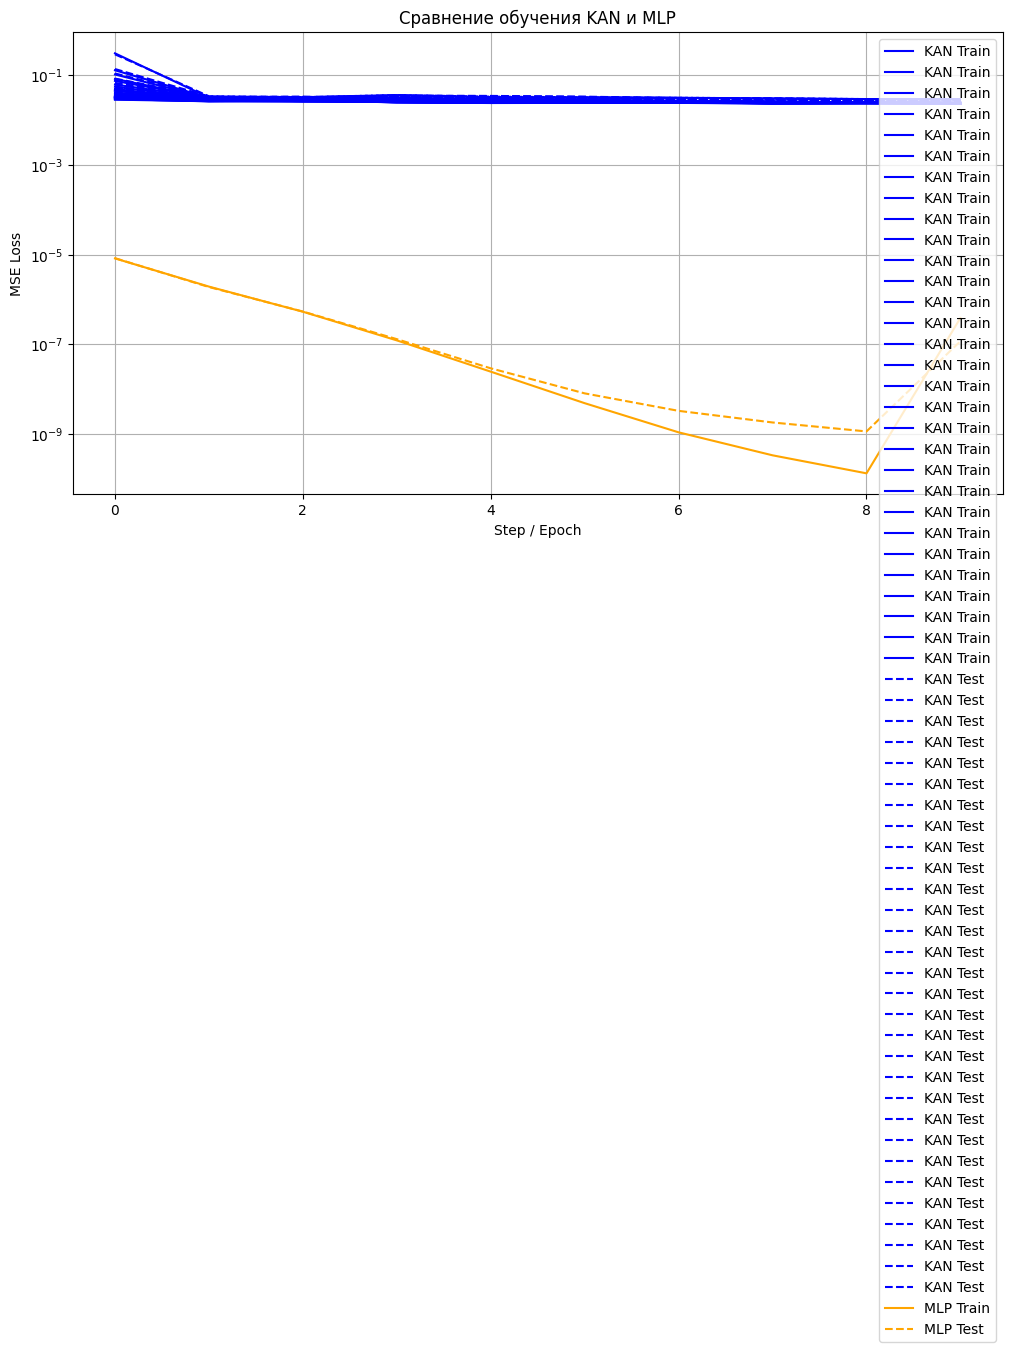

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(train_losses_kan, label='KAN Train', color='blue', linestyle='-')
plt.plot(test_losses_kan,  label='KAN Test',  color='blue', linestyle='--')

plt.plot(train_losses_mlp, label='MLP Train', color='orange', linestyle='-')
plt.plot(test_losses_mlp,  label='MLP Test',  color='orange', linestyle='--')

plt.xlabel('Step / Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.title('Сравнение обучения KAN и MLP')
plt.show()

/tmp/ipykernel_1258/1545579185.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


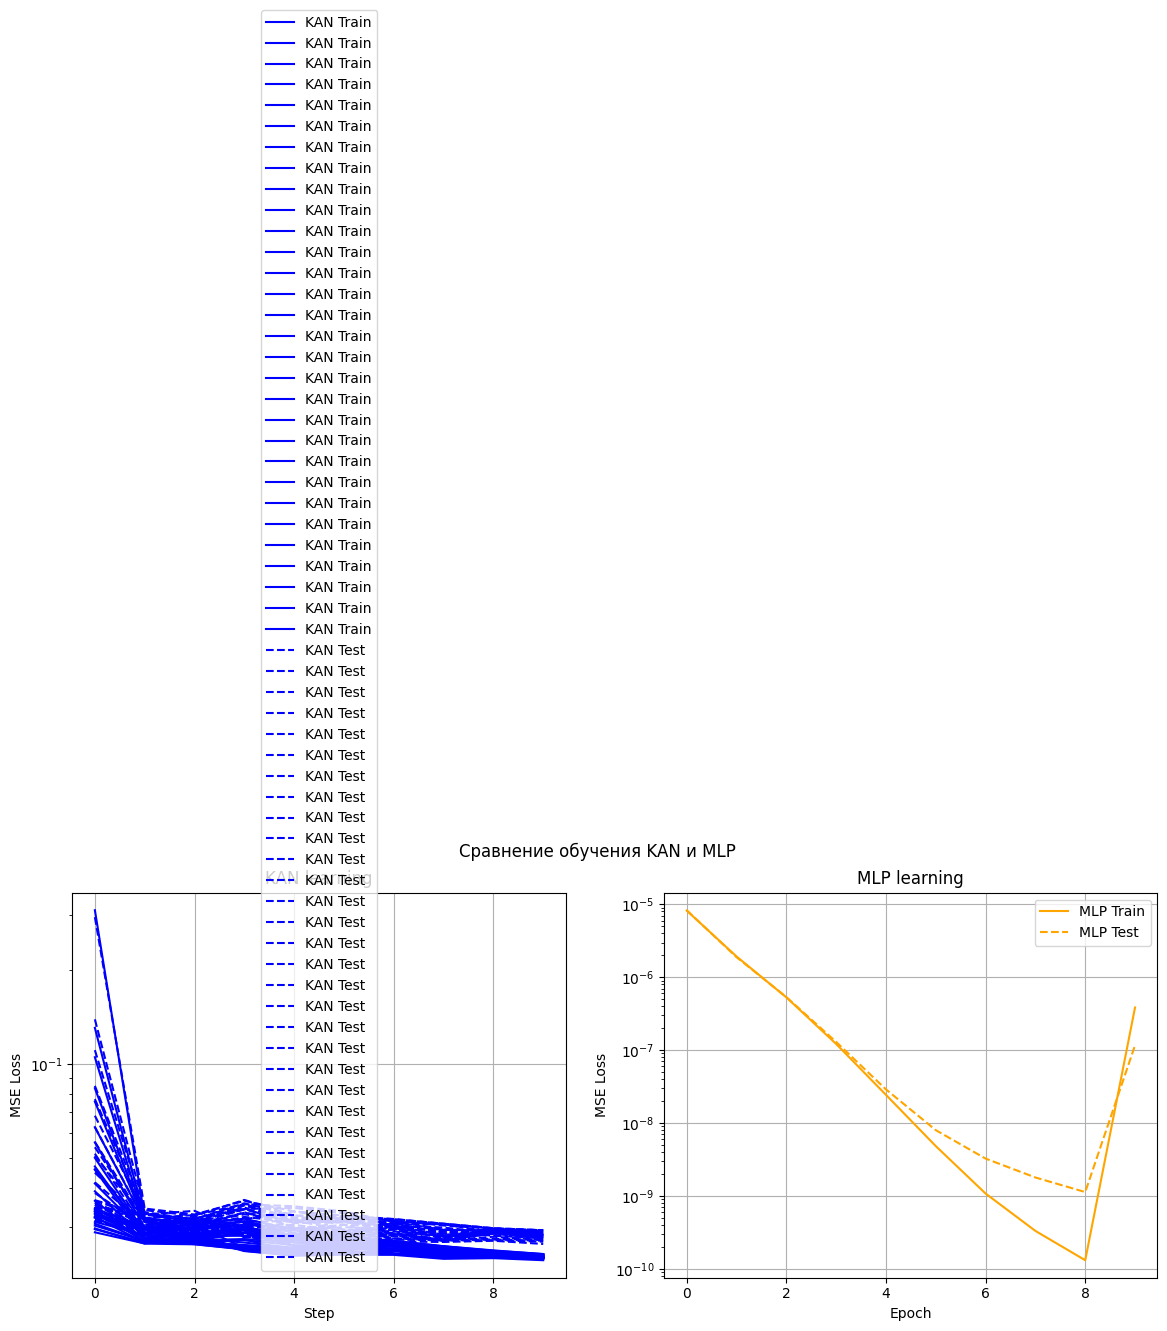

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_kan, label='KAN Train', color='blue')
ax1.plot(test_losses_kan,  label='KAN Test',  color='blue', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('MSE Loss')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True)
ax1.set_title('KAN learning')

ax2.plot(train_losses_mlp, label='MLP Train', color='orange')
ax2.plot(test_losses_mlp,  label='MLP Test',  color='orange', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True)
ax2.set_title('MLP learning')

plt.suptitle('Сравнение обучения KAN и MLP')
plt.tight_layout()
plt.show()